- chiedere a cursor di implementare le contribuzioni nei 4 block

$$
\mathrm{P\&L}
=\Bigg[
\underbrace{\,t\,\overline{\Gamma^{*}}\;\frac{\sigma_{r}+\sigma_{0}}{2}\,(\sigma_{r}-\sigma_{0})\,}_{\text{Volatility premium component}}
\;+\;
\underbrace{\frac{t}{2}\,\rho\;\mathrm{Stdev}\!\big(\Gamma^{*}\big)\;
\mathrm{Stdev}\!\left(\frac{d\langle S\rangle}{S^{2}\,du}\right)}_{\text{Gamma covariance effect}}
\;+\;
\underbrace{e^{-rt}\,\frac{\sigma+\sigma_{0}}{2\sigma}\;
\frac{\partial P}{\partial \sigma}(t)\;(\sigma-\sigma_{0})}_{\text{Vega term}}
\;-\;
\underbrace{\int_{0}^{t}\frac{T-u}{2}\,\big(\sigma^{2}-\sigma_{0}^{2}\big)\,d\Gamma_{u}^{*}}_{\text{dGamma term}}
\;-\;
\underbrace{\int_{0}^{t}\frac{e^{-ru}}{2}\left(\frac{\nu}{\sigma}\,\frac{\partial \nu}{\partial \sigma}\right)\,d\langle\sigma\rangle_{u}}_{\text{Residual drift term}}
\Bigg],
$$


In [1]:
from collections import defaultdict
import pandas as pd
from datetime import date, timedelta
import QuantLib as ql
from dateutil.relativedelta import relativedelta
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from util import VolHandle, option_price, StraddleSelling

In [2]:
total_return = True 

raw_price_p_df = pd.read_excel('data/data.xlsx', sheet_name='prices')
raw_price_tr_df = pd.read_excel('data/data.xlsx', sheet_name='prices_tr')
dividends_df = pd.read_excel('data/data.xlsx', sheet_name='dividends')
riskfree_df = pd.read_excel('data/data.xlsx', sheet_name='riskfree')

if total_return:
    raw_price_df = raw_price_tr_df
else:
    raw_price_df = raw_price_p_df

price_df = raw_price_df.merge(dividends_df, on='date', how="inner").merge(riskfree_df, on='date', how="inner")
price_df['date'] = pd.to_datetime(price_df['date'], format='%d/%m/%y').dt.date
price_df['rate1'] = price_df['rate1']/100
price_df['rate2'] = price_df['rate2']/100
price_df['rate4'] = price_df['rate4']/100
price_df['rate5'] = price_df['rate5']/100

if total_return:
    price_df['div_yield'] = price_df['div_yield']* 0.0
else:
    price_df['div_yield'] = price_df['div_yield']/100
price_df.dropna(inplace=True)
vol_df = pd.read_excel('data/data.xlsx', sheet_name='vols')
vol_df['date'] = pd.to_datetime(vol_df['date']).dt.date

vol_dates = vol_df['date'].unique()
# Filtro price_df per contenere solo le date presenti anche in vol_df
price_df = price_df[price_df['date'].isin(vol_dates)].copy()

# price_df = price_df.iloc[:100].copy()

In [3]:
params = {
    'initial_capital': 100000,
    'max_positions': 21
}

self = StraddleSelling(price_df, vol_df, **params)

In [4]:
results, positions = self.run_backtest()

## Visualizzazioni Delta Hedging


## Strategy Analysis: Delta-Neutral Straddle Selling

### What We're Capturing (with Δ = 0)

**P&L Sources:**


1. **Theta (Time Decay)**: Collect option premium as time passes
2. **Vega (Volatility Risk)**: Profit if Implied Vol > Realized Vol
3. **Gamma Cost**: Pay to maintain delta-neutrality through rebalancing

### Key Findings

- **Total Realized PnL**: $6,038.87 (60 closed positions)
- **Win Rate**: 75% (45 wins, 14 losses)
- **Delta Neutrality**: Perfect (Total Δ = 0)
- **Final Return**: +3.46% over 100 days

### Interpretation

**✅ Profitable Periods** (Low volatility):
- Theta decay > Gamma hedging costs
- Market moves sideways
- Implied volatility decreases

**⚠️ Drawdown Periods** (High volatility):
- Gamma hedging costs > Theta collected
- Large market moves (expensive rebalancing)
- Implied volatility spikes

### Conclusion

The strategy profits when the **market overestimates future volatility** (IV > RV). With 75% win rate and perfect delta-hedging, we successfully harvested the volatility risk premium while remaining market-direction neutral.


In [14]:
results

,Date,Index Price,Index Return,Portfolio_Value,Stock Position (shares),Stock Position Value,Stock PnL (Period),Stock PnL (Cumulative),Straddle Value,Straddle PnL (Unrealized),...,Straddle Vega,Straddle Volga,Active Positions,Can Open New Positions,Total Delta,Gamma Term,Vega Term,dGamma Term,Residual Term,First Order P&L
0,2010-10-19,4619.43,0.000000,100000.000000,0.040156,185.498744,0.000000,0.000000,-232.724635,0.000000,...,10.879701,-0.030859,0,True,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,2010-10-20,4642.53,0.005001,100005.110865,0.148020,687.186286,0.927608,0.927608,-456.681099,4.183257,...,21.549875,0.451340,1,True,0.0,9.656888,0.019857,0.000000,0.000041,9.676786
2,2010-10-21,4692.62,0.010789,100010.954729,0.486753,2284.148346,7.414311,8.341919,-684.884133,2.612810,...,31.933986,6.087987,2,True,0.0,14.984365,0.074356,-0.036155,0.002354,15.024920
3,2010-10-22,4678.70,-0.002966,100028.338538,0.410334,1919.827911,-6.775606,1.566313,-883.163382,26.772225,...,42.609665,4.082191,3,True,0.0,36.012274,0.144190,-0.555895,0.006574,35.607143
4,2010-10-25,4675.03,-0.000784,100078.021911,0.411252,1922.615182,-1.505924,0.060389,-1050.438591,77.961522,...,51.237294,3.797093,4,True,0.0,64.710450,0.176939,-1.608919,0.011503,63.289973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3810,2025-09-24,13282.65,-0.001430,126458.178290,0.907638,12055.834538,-20.165861,-32248.220616,-255.393971,225.513703,...,3.902863,41.480321,4,False,0.0,54432.380870,0.406132,-15759.391136,2526.965416,41200.361282
3811,2025-09-25,13234.84,-0.003599,126469.918354,0.553903,7330.823977,-43.394161,-32291.614777,-145.619412,176.374893,...,3.125878,26.752576,3,False,0.0,54445.194944,0.407243,-15759.053567,2526.971319,41213.519939
3812,2025-09-26,13375.07,0.010596,126459.061572,0.347350,4645.830846,77.673885,-32213.940891,-136.950334,26.161594,...,0.529496,12.466488,2,False,0.0,54444.667078,0.415870,-15760.437279,2526.974351,41211.620020
3813,2025-09-29,13392.46,0.001300,126460.953018,0.000000,0.000000,6.040417,-32207.900474,0.000000,0.000000,...,0.000000,0.000000,1,False,0.0,54444.667078,0.415870,-15760.437279,2526.974351,41211.620020


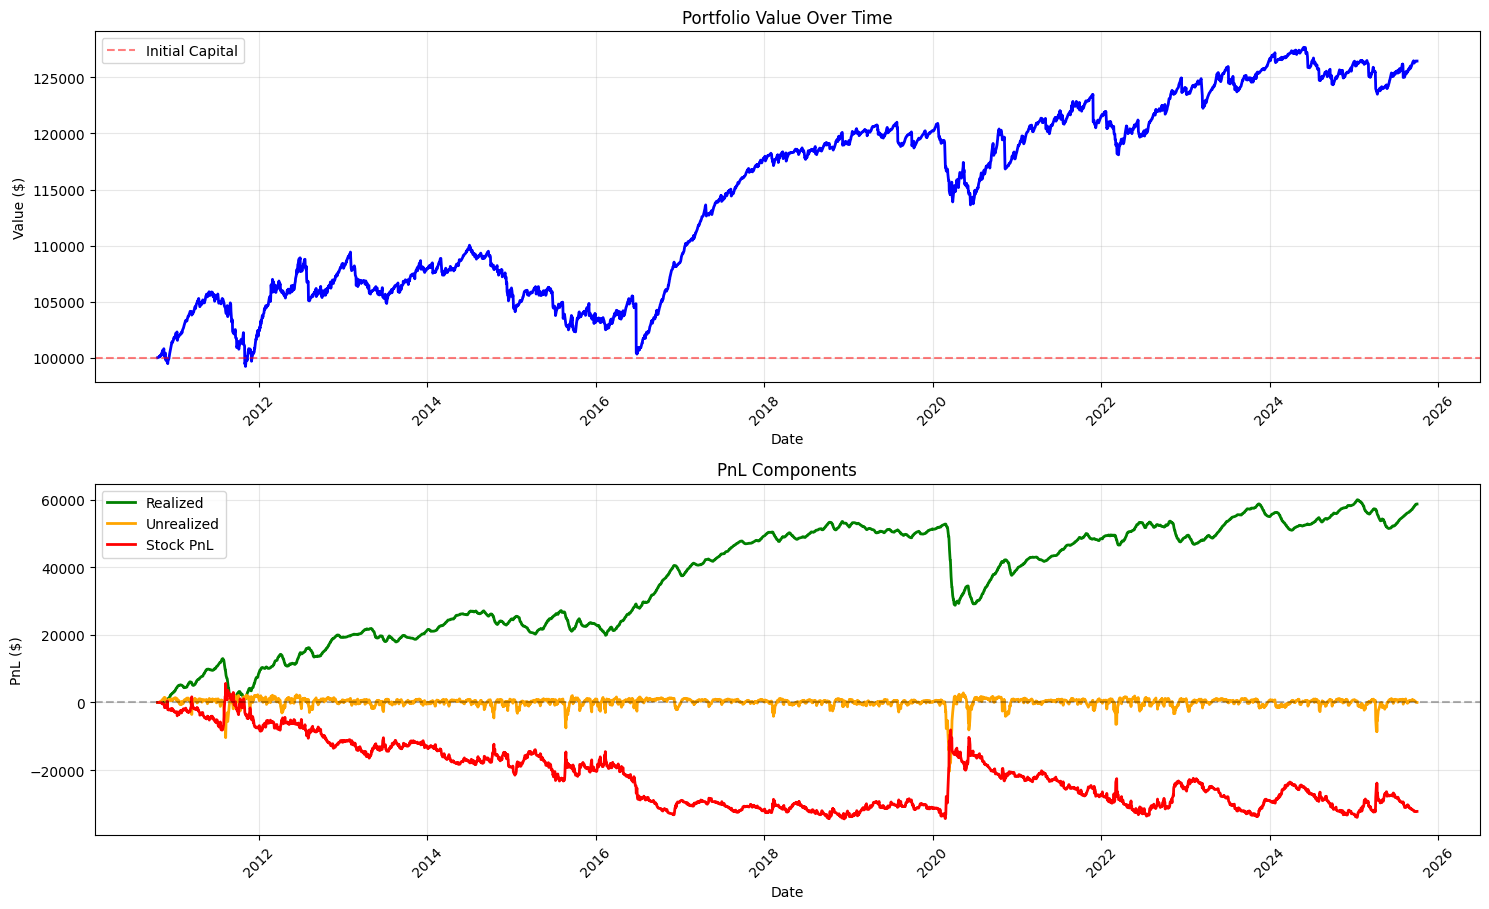

In [17]:
import matplotlib.pyplot as plt

# Assicurati che la colonna 'Date' sia in formato datetime (se non lo è già)
if not hasattr(results['Date'].iloc[0], 'year'):
    results['Date'] = pd.to_datetime(results['Date'])

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
# fig.suptitle('Delta Hedging Analysis', fontsize=16, fontweight='bold')

# 1. Portfolio Value (Top plot)
axes[0].plot(results['Date'], results['Portfolio_Value'], linewidth=2, color='blue')
axes[0].axhline(y=100000, color='r', linestyle='--', alpha=0.5, label='Initial Capital')
axes[0].set_title('Portfolio Value Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 2. PnL Components (Bottom plot)
axes[1].plot(results['Date'], results['Straddle PnL (Realized)'], label='Realized', linewidth=2, color='green')
axes[1].plot(results['Date'], results['Straddle PnL (Unrealized)'], label='Unrealized', linewidth=2, color='orange')
axes[1].plot(results['Date'], results['Stock PnL (Cumulative)'], label='Stock PnL', linewidth=2, color='red')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_title('PnL Components')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('PnL ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [6]:
aa

NameError: name 'aa' is not defined

In [ ]:
results

,Date,Index Price,Index Return,Portfolio_Value,Stock Position (shares),Stock Position Value,Stock PnL (Period),Stock PnL (Cumulative),Straddle Value,Straddle PnL (Unrealized),...,Straddle Vega,Straddle Volga,Active Positions,Can Open New Positions,Total Delta,Gamma Term,Vega Term,dGamma Term,Residual Term,First Order P&L
0,2010-10-19,4619.43,0.000000,100000.000000,0.040156,185.498744,0.000000,0.000000,-232.724635,0.000000,...,10.879701,-0.030859,0,True,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,2010-10-20,4642.53,0.005001,100005.110865,0.148020,687.186286,0.927608,0.927608,-456.681099,4.183257,...,21.549875,0.451340,1,True,0.0,9.656888,0.019857,0.000000,0.000041,9.676786
2,2010-10-21,4692.62,0.010789,100010.954729,0.486753,2284.148346,7.414311,8.341919,-684.884133,2.612810,...,31.933986,6.087987,2,True,0.0,14.984365,0.074356,-0.036155,0.002354,15.024920
3,2010-10-22,4678.70,-0.002966,100028.338538,0.410334,1919.827911,-6.775606,1.566313,-883.163382,26.772225,...,42.609665,4.082191,3,True,0.0,36.012274,0.144190,-0.555895,0.006574,35.607143
4,2010-10-25,4675.03,-0.000784,100078.021911,0.411252,1922.615182,-1.505924,0.060389,-1050.438591,77.961522,...,51.237294,3.797093,4,True,0.0,64.710450,0.176939,-1.608919,0.011503,63.289973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3810,2025-09-24,13282.65,-0.001430,126458.178290,0.907638,12055.834538,-20.165861,-32248.220616,-255.393971,225.513703,...,3.902863,41.480321,4,False,0.0,54432.380870,0.406132,-15759.391136,2526.965416,41200.361282
3811,2025-09-25,13234.84,-0.003599,126469.918354,0.553903,7330.823977,-43.394161,-32291.614777,-145.619412,176.374893,...,3.125878,26.752576,3,False,0.0,54445.194944,0.407243,-15759.053567,2526.971319,41213.519939
3812,2025-09-26,13375.07,0.010596,126459.061572,0.347350,4645.830846,77.673885,-32213.940891,-136.950334,26.161594,...,0.529496,12.466488,2,False,0.0,54444.667078,0.415870,-15760.437279,2526.974351,41211.620020
3813,2025-09-29,13392.46,0.001300,126460.953018,0.000000,0.000000,6.040417,-32207.900474,0.000000,0.000000,...,0.000000,0.000000,1,False,0.0,54444.667078,0.415870,-15760.437279,2526.974351,41211.620020


---
## P&L Decomposition Analysis

### Formula Components

The P&L is decomposed into four main terms according to the equation shown at the top:

$$
\mathrm{P\&L} = \text{Gamma term} + \text{Vega term} - \text{dGamma term} - \text{Residual drift term}
$$

1. **Gamma Term**: Captures P&L from convexity (gamma trading)
   - Profit/loss from the difference between realized and implied volatility
   - Formula: $\frac{1}{2} \Gamma^* \left(\frac{r_t^2}{\Delta t} - \sigma_0^2\right) \Delta t$

2. **Vega Term**: Captures P&L from changes in implied volatility
   - Uses $F_t$ that "nets" to approximately zero over the position's life
   - Formula: $\Delta F_t$ where $F_t = \frac{\sigma_t + \sigma_0}{2\sigma_t} \mathcal{V} (\sigma_t - \sigma_0)$

3. **dGamma Term**: Captures the effect of gamma changing over time
   - Integral of gamma changes weighted by vol difference
   - Formula: $-\frac{\tau}{2}(\sigma_t^2 - \sigma_0^2) d\Gamma^*$

4. **Residual Drift Term**: Captures second-order volatility effects
   - Related to volga (volatility of volatility)
   - Formula: $-\frac{1}{2} e^{-ru} \frac{\mathcal{V}}{\sigma} \mathcal{W} (d\sigma)^2$

### Interpretation

- **First Order P&L** = Sum of all four terms
- Should track closely with the actual P&L from the strategy
- Differences indicate higher-order effects or model limitations
---


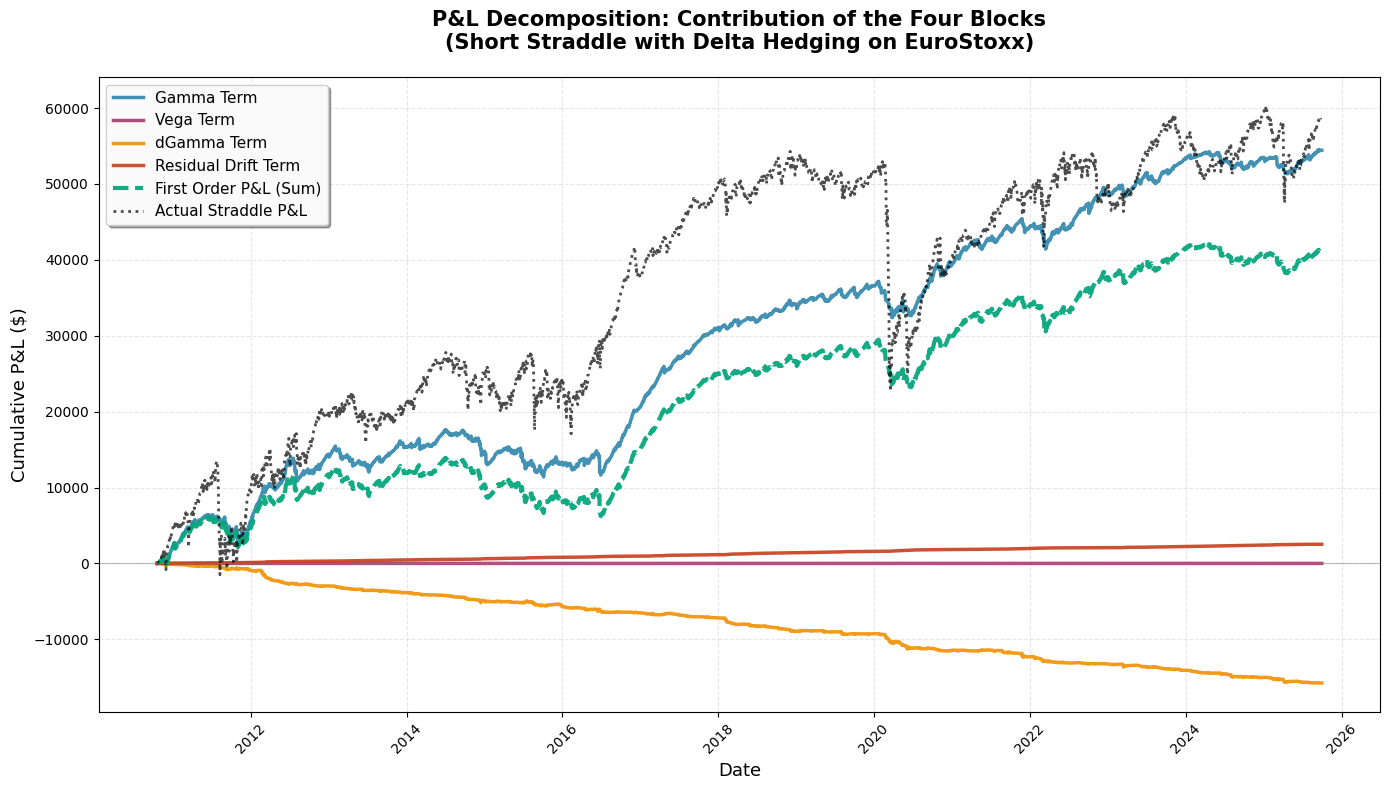


P&L DECOMPOSITION SUMMARY

Final Gamma Term:        $   54,444.67
Final Vega Term:         $        0.42
Final dGamma Term:       $  -15,760.44
Final Residual Term:     $    2,526.97
----------------------------------------------------------------------
First Order P&L:         $   41,211.62
Actual Straddle P&L:     $   58,668.85
Difference:              $   17,457.23

Explained Ratio:                70.24%


In [ ]:
# P&L Decomposition Plot - replicating Figure 2 style from straddle_gpt.ipynb
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))

# Plot each component with distinct colors
ax.plot(results['Date'], results['Gamma Term'], 
        label='Gamma Term', linewidth=2.5, color='#2E86AB', alpha=0.9)
ax.plot(results['Date'], results['Vega Term'], 
        label='Vega Term', linewidth=2.5, color='#A23B72', alpha=0.9)
ax.plot(results['Date'], results['dGamma Term'], 
        label='dGamma Term', linewidth=2.5, color='#F18F01', alpha=0.9)
ax.plot(results['Date'], results['Residual Term'], 
        label='Residual Drift Term', linewidth=2.5, color='#C73E1D', alpha=0.9)
ax.plot(results['Date'], results['First Order P&L'], 
        label='First Order P&L (Sum)', linewidth=3, color='#06A77D', linestyle='--', alpha=0.95)

# Also plot actual P&L for comparison
ax.plot(results['Date'], results['Straddle PnL (Total)'], 
        label='Actual Straddle P&L', linewidth=2, color='black', 
        linestyle=':', alpha=0.7)

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_title('P&L Decomposition: Contribution of the Four Blocks\n(Short Straddle with Delta Hedging on EuroStoxx)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Cumulative P&L ($)', fontsize=13)
ax.legend(loc='best', fontsize=11, framealpha=0.95, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("P&L DECOMPOSITION SUMMARY")
print("="*70)
print(f"\nFinal Gamma Term:        ${results['Gamma Term'].iloc[-1]:>12,.2f}")
print(f"Final Vega Term:         ${results['Vega Term'].iloc[-1]:>12,.2f}")
print(f"Final dGamma Term:       ${results['dGamma Term'].iloc[-1]:>12,.2f}")
print(f"Final Residual Term:     ${results['Residual Term'].iloc[-1]:>12,.2f}")
print("-" * 70)
print(f"First Order P&L:         ${results['First Order P&L'].iloc[-1]:>12,.2f}")
print(f"Actual Straddle P&L:     ${results['Straddle PnL (Total)'].iloc[-1]:>12,.2f}")
print(f"Difference:              ${results['Straddle PnL (Total)'].iloc[-1] - results['First Order P&L'].iloc[-1]:>12,.2f}")
print(f"\nExplained Ratio:         {100 * results['First Order P&L'].iloc[-1] / results['Straddle PnL (Total)'].iloc[-1]:>12.2f}%")
print("="*70)


In [ ]:
# Display last 30 days of P&L decomposition
print("\n" + "="*100)
print("LAST 30 DAYS - P&L DECOMPOSITION DETAIL")
print("="*100 + "\n")

decomp_cols = ['Date', 'Index Price', 'Gamma Term', 'Vega Term', 'dGamma Term', 
               'Residual Term', 'First Order P&L', 'Straddle PnL (Total)']
display_df = results[decomp_cols].tail(30).copy()
display_df.set_index('Date', inplace=True)

# Format numbers for better readability
for col in display_df.columns:
    if col != 'Index Price':
        display_df[col] = display_df[col].apply(lambda x: f"${x:>10,.2f}")
    else:
        display_df[col] = display_df[col].apply(lambda x: f"{x:>8,.2f}")

print(display_df.to_string())

# Correlation analysis
print("\n\n" + "="*60)
print("CORRELATION BETWEEN P&L COMPONENTS")
print("="*60 + "\n")
corr_cols = ['Gamma Term', 'Vega Term', 'dGamma Term', 'Residual Term']
correlation_matrix = results[corr_cols].corr()
print(correlation_matrix.round(3).to_string())



LAST 30 DAYS - P&L DECOMPOSITION DETAIL

           Index Price   Gamma Term    Vega Term  dGamma Term Residual Term First Order P&L Straddle PnL (Total)
Date                                                                                                            
2025-08-20   13,299.47  $ 53,782.45  $     -0.92  $-15,738.98   $  2,523.66     $ 40,566.21          $ 55,901.11
2025-08-21   13,274.80  $ 53,848.25  $     -0.81  $-15,733.56   $  2,524.60     $ 40,638.48          $ 56,063.72
2025-08-22   13,338.15  $ 53,893.06  $      0.36  $-15,739.37   $  2,524.79     $ 40,678.84          $ 55,966.95
2025-08-25   13,230.56  $ 53,906.51  $      0.21  $-15,734.19   $  2,524.92     $ 40,697.45          $ 56,504.82
2025-08-26   13,084.70  $ 53,855.53  $     -0.29  $-15,725.70   $  2,525.09     $ 40,654.63          $ 56,785.12
2025-08-27   13,107.52  $ 53,959.74  $     -0.35  $-15,725.14   $  2,525.28     $ 40,759.52          $ 56,825.10
2025-08-28   13,116.42  $ 54,056.50  $     -0.03  $-15

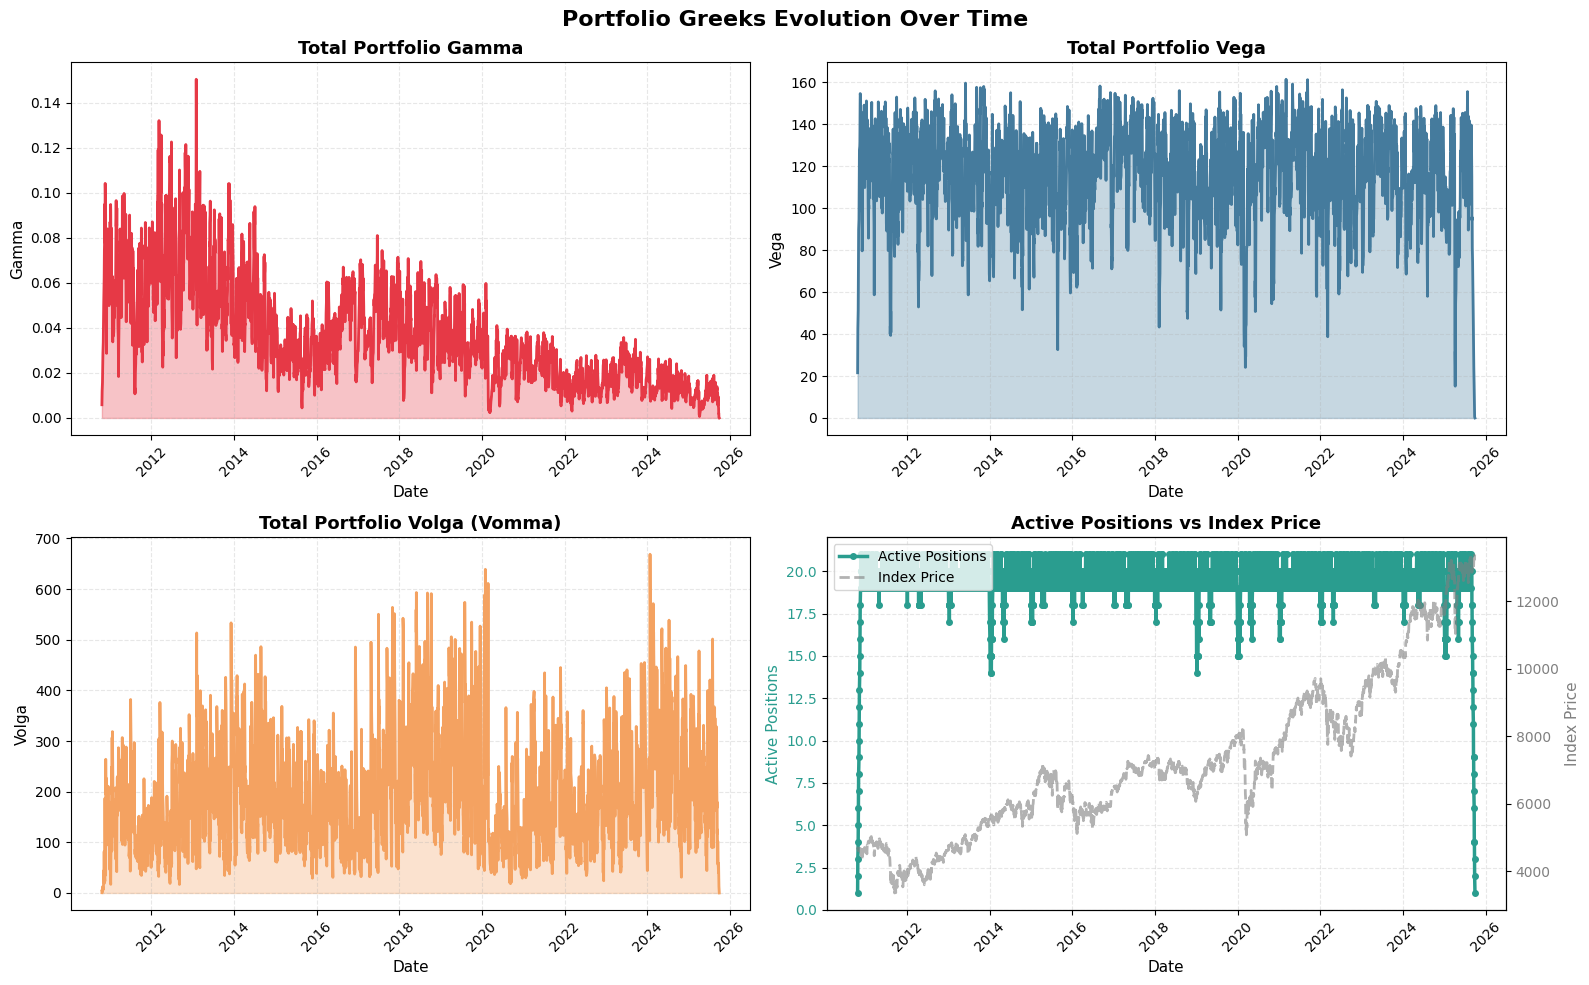


PORTFOLIO GREEKS STATISTICS

Average Gamma (active periods):       0.0369
Average Vega (active periods):      117.8069
Average Volga (active periods):   194.711164

Max Gamma:       0.1505
Max Vega:      161.4559
Max Volga:   668.828276

Min Gamma:       0.0000
Min Vega:        0.0000
Min Volga:     0.000000


In [ ]:
# Greeks Evolution Over Time
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Greeks Evolution Over Time', fontsize=16, fontweight='bold')

# Filter to only show periods with active positions
active_results = results[results['Active Positions'] > 0].copy()

# Gamma
axes[0, 0].plot(active_results['Date'], active_results['Straddle Gamma'], 
                linewidth=2, color='#E63946')
axes[0, 0].fill_between(active_results['Date'], 0, active_results['Straddle Gamma'], 
                        alpha=0.3, color='#E63946')
axes[0, 0].set_title('Total Portfolio Gamma', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Date', fontsize=11)
axes[0, 0].set_ylabel('Gamma', fontsize=11)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].tick_params(axis='x', rotation=45)

# Vega
axes[0, 1].plot(active_results['Date'], active_results['Straddle Vega'], 
                linewidth=2, color='#457B9D')
axes[0, 1].fill_between(active_results['Date'], 0, active_results['Straddle Vega'], 
                        alpha=0.3, color='#457B9D')
axes[0, 1].set_title('Total Portfolio Vega', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Date', fontsize=11)
axes[0, 1].set_ylabel('Vega', fontsize=11)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=45)

# Volga
axes[1, 0].plot(active_results['Date'], active_results['Straddle Volga'], 
                linewidth=2, color='#F4A261')
axes[1, 0].fill_between(active_results['Date'], 0, active_results['Straddle Volga'], 
                        alpha=0.3, color='#F4A261')
axes[1, 0].set_title('Total Portfolio Volga (Vomma)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].set_ylabel('Volga', fontsize=11)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].tick_params(axis='x', rotation=45)

# Active Positions vs Index Price
ax1 = axes[1, 1]
ax2 = ax1.twinx()

line1 = ax1.plot(active_results['Date'], active_results['Active Positions'], 
         linewidth=2.5, color='#2A9D8F', label='Active Positions', marker='o', markersize=4)
line2 = ax2.plot(active_results['Date'], active_results['Index Price'], 
         linewidth=2, color='gray', alpha=0.6, linestyle='--', label='Index Price')

ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Active Positions', color='#2A9D8F', fontsize=11)
ax2.set_ylabel('Index Price', color='gray', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2A9D8F')
ax2.tick_params(axis='y', labelcolor='gray')
ax1.set_title('Active Positions vs Index Price', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Summary statistics for greeks
print("\n" + "="*60)
print("PORTFOLIO GREEKS STATISTICS")
print("="*60)
print(f"\nAverage Gamma (active periods): {active_results['Straddle Gamma'].mean():>12,.4f}")
print(f"Average Vega (active periods):  {active_results['Straddle Vega'].mean():>12,.4f}")
print(f"Average Volga (active periods): {active_results['Straddle Volga'].mean():>12,.6f}")
print(f"\nMax Gamma: {active_results['Straddle Gamma'].max():>12,.4f}")
print(f"Max Vega:  {active_results['Straddle Vega'].max():>12,.4f}")
print(f"Max Volga: {active_results['Straddle Volga'].max():>12,.6f}")
print(f"\nMin Gamma: {active_results['Straddle Gamma'].min():>12,.4f}")
print(f"Min Vega:  {active_results['Straddle Vega'].min():>12,.4f}")
print(f"Min Volga: {active_results['Straddle Volga'].min():>12,.6f}")
print("="*60)


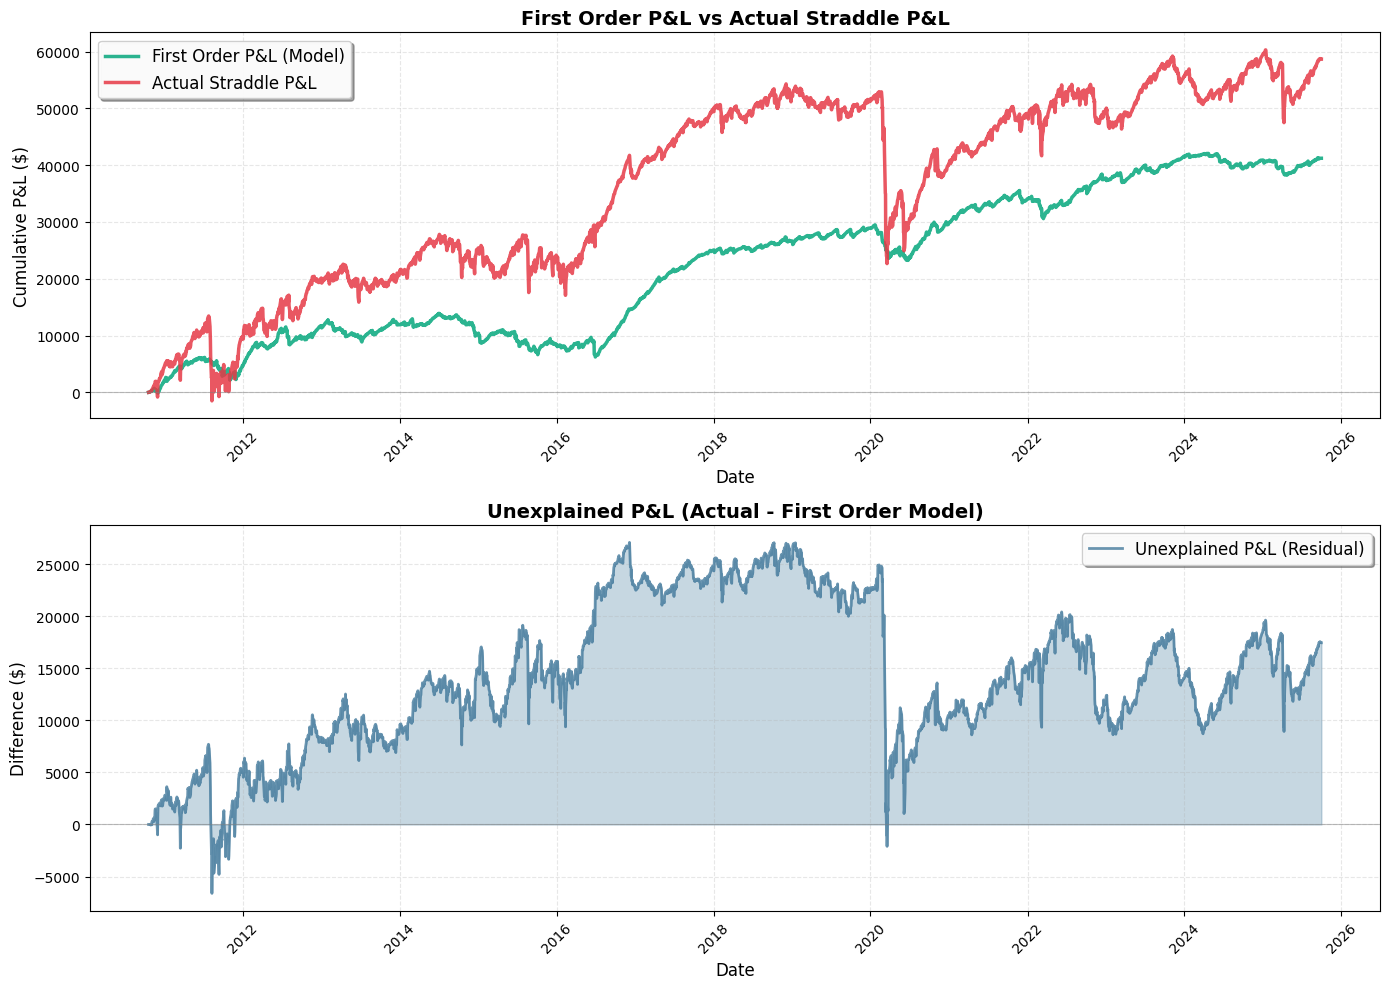


MODEL FIT STATISTICS

Root Mean Square Error (RMSE):  $   15,858.61
Mean Absolute Error (MAE):      $   14,269.94
Maximum Absolute Error:         $   27,098.28
Final P&L Explained:                   70.24%

COMPONENT CONTRIBUTIONS (% of First Order P&L)

Gamma Term:              132.11%
Vega Term:                 0.00%
dGamma Term:             -38.24%
Residual Term:             6.13%
----------------------------------------------------------------------
Total:                   100.00%


In [ ]:
# Comparison: First Order P&L vs Actual P&L
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: Both P&Ls overlaid
axes[0].plot(results['Date'], results['First Order P&L'], 
             label='First Order P&L (Model)', linewidth=2.5, color='#06A77D', alpha=0.85)
axes[0].plot(results['Date'], results['Straddle PnL (Total)'], 
             label='Actual Straddle P&L', linewidth=2.5, color='#E63946', alpha=0.85)
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
axes[0].set_title('First Order P&L vs Actual Straddle P&L', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Cumulative P&L ($)', fontsize=12)
axes[0].legend(loc='best', fontsize=12, framealpha=0.95, shadow=True)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

# Bottom plot: Difference (residual unexplained)
difference = results['Straddle PnL (Total)'] - results['First Order P&L']
axes[1].plot(results['Date'], difference, 
             linewidth=2, color='#457B9D', alpha=0.8, label='Unexplained P&L (Residual)')
axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].fill_between(results['Date'], 0, difference, alpha=0.3, color='#457B9D')
axes[1].set_title('Unexplained P&L (Actual - First Order Model)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Difference ($)', fontsize=12)
axes[1].legend(loc='best', fontsize=12, framealpha=0.95, shadow=True)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistics on model fit
print("\n" + "="*70)
print("MODEL FIT STATISTICS")
print("="*70)
rmse = np.sqrt(np.mean(difference**2))
mae = np.mean(np.abs(difference))
max_error = np.abs(difference).max()
final_explained_pct = 100 * results['First Order P&L'].iloc[-1] / results['Straddle PnL (Total)'].iloc[-1]

print(f"\nRoot Mean Square Error (RMSE):  ${rmse:>12,.2f}")
print(f"Mean Absolute Error (MAE):      ${mae:>12,.2f}")
print(f"Maximum Absolute Error:         ${max_error:>12,.2f}")
print(f"Final P&L Explained:            {final_explained_pct:>12.2f}%")

# Contribution breakdown (percentage)
print("\n" + "="*70)
print("COMPONENT CONTRIBUTIONS (% of First Order P&L)")
print("="*70)
total_fo = results['First Order P&L'].iloc[-1]
if abs(total_fo) > 1e-6:
    gamma_pct = 100 * results['Gamma Term'].iloc[-1] / total_fo
    vega_pct = 100 * results['Vega Term'].iloc[-1] / total_fo
    dgamma_pct = 100 * results['dGamma Term'].iloc[-1] / total_fo
    residual_pct = 100 * results['Residual Term'].iloc[-1] / total_fo
    
    print(f"\nGamma Term:          {gamma_pct:>10.2f}%")
    print(f"Vega Term:           {vega_pct:>10.2f}%")
    print(f"dGamma Term:         {dgamma_pct:>10.2f}%")
    print(f"Residual Term:       {residual_pct:>10.2f}%")
    print("-" * 70)
    print(f"Total:               {gamma_pct + vega_pct + dgamma_pct + residual_pct:>10.2f}%")
else:
    print("\nFirst Order P&L is near zero, cannot calculate percentages.")
print("="*70)
